In [3]:
import os
from pathlib import Path
cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [8]:
import os
import math
import numpy as np
import torch
import matplotlib.pyplot as plt
import re
from collections import defaultdict

RESULTS_PATH = "data/experiments/cls_patching/vitbase_neutrality/single_patching_results.pt" 

results = torch.load(RESULTS_PATH, map_location="cpu", weights_only=False)

print("Top keys:", list(results.keys()))
print("Original keys:", list(results["original"].keys()))
print("Corrupted keys:", list(results["corrupted"].keys()))
print("Patched layer example keys:", list(results["patched"].keys())[:3])

def _to_np(x):
    if x is None:
        return None
    if isinstance(x, np.ndarray):
        return x
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.array(x)

emo_map = results.get("emotion_map", {})
idx2name = emo_map if isinstance(emo_map, dict) else None

orig_final = _to_np(results["original"]["final_probs"])[0]   # [C]
corr_final = _to_np(results["corrupted"]["final_probs"])[0]  # [C]
C = orig_final.shape[0]
print("C =", C)


Top keys: ['original', 'corrupted', 'patched', 'emotion_map']
Original keys: ['metadata', 'final_probs', 'layer_probs']
Corrupted keys: ['metadata', 'final_probs', 'layer_probs']
Patched layer example keys: ['layer_0', 'layer_1', 'layer_2']
C = 6


In [9]:
def get_true_class_index(results):
    md = results.get("original", {}).get("metadata", {})
    for k in ["label", "emotion_id", "target", "y", "class_id", "true_label", "emotion"]:
        if isinstance(md, dict) and k in md:
            v = md[k]
            if isinstance(v, (list, tuple)) and len(v) == 1:
                v = v[0]
            if isinstance(v, (np.integer, int)):
                return int(v)
            if isinstance(v, str) and isinstance(results.get("emotion_map", {}), dict):
                inv = {name: idx for idx, name in results["emotion_map"].items()}
                if v in inv:
                    return int(inv[v])
    return int(_to_np(results["original"]["final_probs"])[0].argmax())

TRUE_C = get_true_class_index(results)
true_name = idx2name.get(TRUE_C, str(TRUE_C)) if idx2name else str(TRUE_C)
print("TRUE_C =", TRUE_C, "| name =", true_name)

def pretty_label(i):
    if idx2name:
        return str(idx2name.get(int(i), i))
    return str(i)


TRUE_C = 1 | name = happiness


In [ ]:
def list_layer_indices_from_dict(d):
    out = []
    for k in d.keys():
        m = re.match(r"layer_(\d+)", k)
        if m:
            out.append(int(m.group(1)))
    return sorted(out)

layer_keys = list(results["original"]["layer_probs"].keys())
layers = list_layer_indices_from_dict(results["original"]["layer_probs"])
print("Layers:", layers)

first_layer_key = f"layer_{layers[0]}"
streams = list(results["patched"][first_layer_key].keys())
print("Streams:", streams)

def get_layer_probs(split, layer_i):
    return _to_np(results[split]["layer_probs"][f"layer_{layer_i}"])[0]  # [C]

def get_probe_next_probs(layer_i, stream):
    obj = results["patched"][f"layer_{layer_i}"][stream]["patch_0"]
    p = obj.get("probe_next_layer_probs", None)
    return None if p is None else _to_np(p)[0]  # [C]

def get_final_probs(layer_i, stream):
    obj = results["patched"][f"layer_{layer_i}"][stream]["patch_0"]
    return _to_np(obj["final_probs"])[0]  # [C]


Layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
Streams: ['block_output', 'attention_output', 'mlp_activation']


In [ ]:
plt.figure(figsize=(10,4))
x = np.arange(C)
plt.plot(x, orig_final, marker="o", label="original final")
plt.plot(x, corr_final, marker="o", label="corrupted final")
plt.xticks(x, [pretty_label(i) for i in x], rotation=30, ha="right")
plt.ylabel("probability")
plt.title("Final head: original vs corrupted (reference)")
plt.legend()
plt.tight_layout()
plt.show()

for L in layers:
    for stream in streams:
        patched_final = get_final_probs(L, stream)
        d = float(orig_final[TRUE_C] - patched_final[TRUE_C])
        plt.figure(figsize=(10,3))
        plt.plot(x, orig_final, marker="o", label="original final")
        plt.plot(x, patched_final, marker="o", label=f"patched final (L={L}, {stream})")
        plt.xticks(x, [pretty_label(i) for i in x], rotation=30, ha="right")
        plt.ylabel("probability")
        plt.title(f"Final probs after CLS patch at layer {L}, stream={stream} | Δ(correct)=orig-patched={d:.6f}")
        plt.legend()
        plt.tight_layout()
        plt.show()


valid layers for next-probe: [0, 1, 2, 3, 4] ... [6, 7, 8, 9, 10]


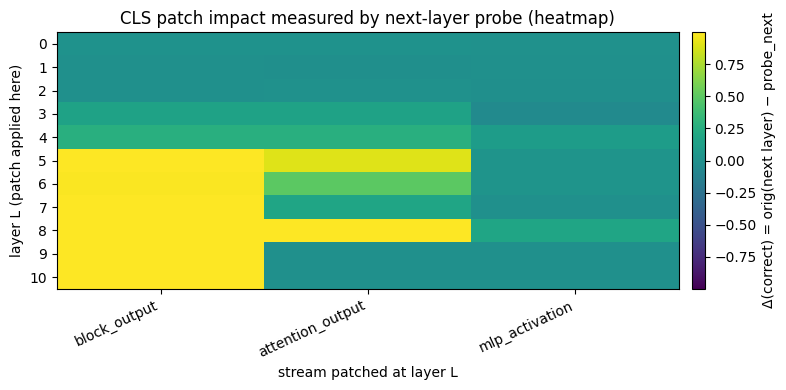

In [ ]:
valid_layers = [L for L in layers if (f"layer_{L}" in results["patched"])]

def has_next(L):
    return (L + 1) in layers

valid_layers = [L for L in valid_layers if has_next(L)]
print("valid layers for next-probe:", valid_layers[:5], "...", valid_layers[-5:])

D = np.zeros((len(valid_layers), len(streams)), dtype=np.float32)

for i, L in enumerate(valid_layers):
    orig_next = get_layer_probs("original", L+1)
    for j, stream in enumerate(streams):
        probe = get_probe_next_probs(L, stream)
        if probe is None:
            D[i, j] = np.nan
        else:
            D[i, j] = float(orig_next[TRUE_C] - probe[TRUE_C])

finite = D[np.isfinite(D)]
v = np.quantile(np.abs(finite), 0.99) if finite.size else 1e-6
v = float(v if v > 0 else 1e-6)

plt.figure(figsize=(8, max(4, 0.35*len(valid_layers))))
im = plt.imshow(D, aspect="auto", interpolation="nearest", vmin=-v, vmax=v)
plt.colorbar(im, fraction=0.03, pad=0.02, label="Δ(correct) = orig(next layer) − probe_next")
plt.yticks(np.arange(len(valid_layers)), valid_layers)
plt.xticks(np.arange(len(streams)), streams, rotation=25, ha="right")
plt.xlabel("stream patched at layer L")
plt.ylabel("layer L (patch applied here)")
plt.title("CLS patch impact measured by next-layer probe (heatmap)")
plt.tight_layout()
plt.show()


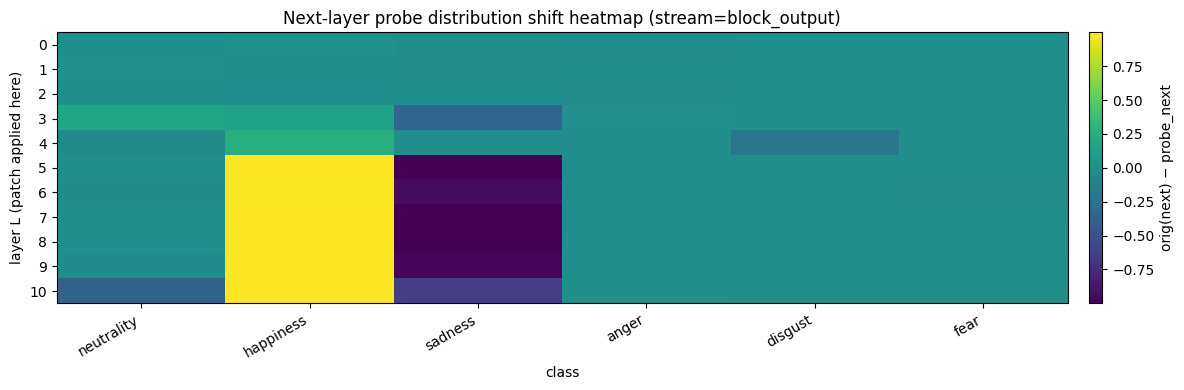

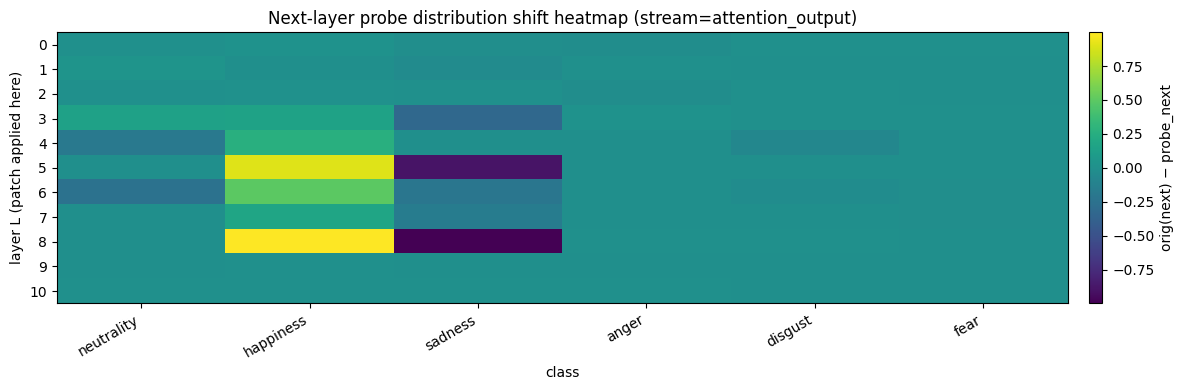

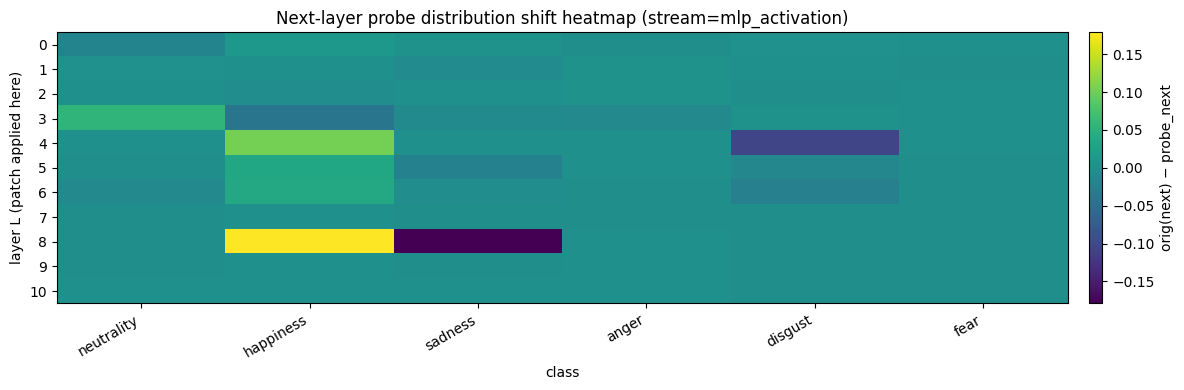

In [ ]:
for i in range(len(streams)):    
    STREAM_TO_PLOT = streams[i]
    M = np.zeros((len(valid_layers), C), dtype=np.float32)

    for i, L in enumerate(valid_layers):
        orig_next = get_layer_probs("original", L+1)         
        probe = get_probe_next_probs(L, STREAM_TO_PLOT)      
        M[i] = orig_next - probe                             

    finite = M[np.isfinite(M)]
    v = np.quantile(np.abs(finite), 0.99) if finite.size else 1e-6
    v = float(v if v > 0 else 1e-6)

    plt.figure(figsize=(12, max(4, 0.35*len(valid_layers))))
    im = plt.imshow(M, aspect="auto", interpolation="nearest", vmin=-v, vmax=v)
    plt.colorbar(im, fraction=0.03, pad=0.02, label="orig(next) − probe_next")
    plt.yticks(np.arange(len(valid_layers)), valid_layers)
    plt.xticks(np.arange(C), [pretty_label(i) for i in range(C)], rotation=30, ha="right")
    plt.xlabel("class")
    plt.ylabel("layer L (patch applied here)")
    plt.title(f"Next-layer probe distribution shift heatmap (stream={STREAM_TO_PLOT})")
    plt.tight_layout()
    plt.show()


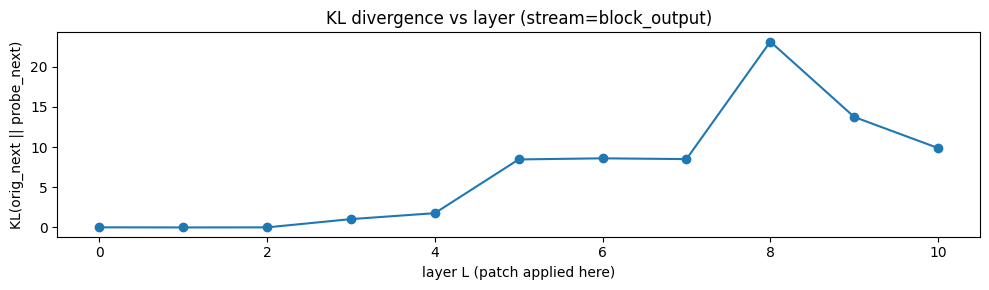

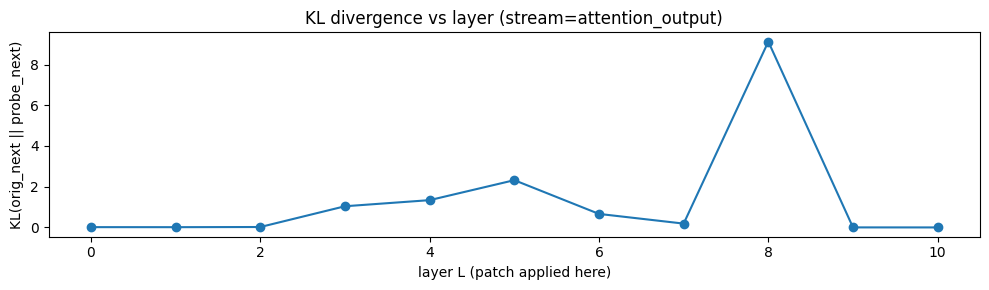

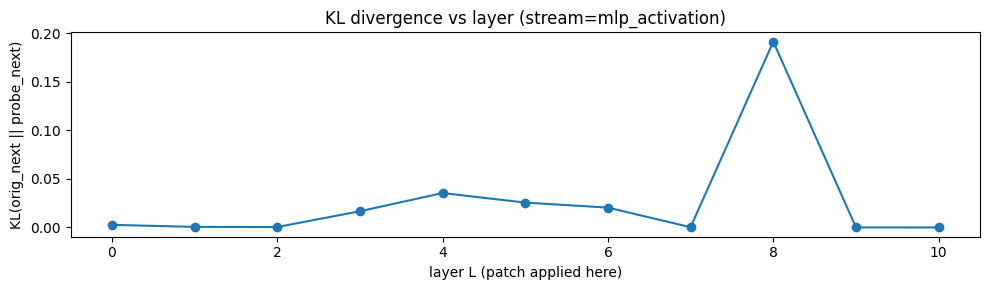

In [19]:
def safe_probs(p, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    p = np.clip(p, eps, 1.0)
    return p / p.sum()

def kl(p, q):
    p = safe_probs(p); q = safe_probs(q)
    return float(np.sum(p * (np.log(p) - np.log(q))))

def js(p, q):
    p = safe_probs(p); q = safe_probs(q)
    m = 0.5*(p+q)
    return 0.5*kl(p,m) + 0.5*kl(q,m)

def l1(p, q):
    p = safe_probs(p); q = safe_probs(q)
    return float(np.sum(np.abs(p-q)))

for stream in streams:
    KL, JS, L1 = [], [], []
    for L in valid_layers:
        orig_next = get_layer_probs("original", L+1)
        probe = get_probe_next_probs(L, stream)
        KL.append(kl(orig_next, probe))
        JS.append(js(orig_next, probe))
        L1.append(l1(orig_next, probe))

    plt.figure(figsize=(10,3))
    plt.plot(valid_layers, KL, marker="o")
    plt.xlabel("layer L (patch applied here)")
    plt.ylabel("KL(orig_next || probe_next)")
    plt.title(f"KL divergence vs layer (stream={stream})")
    plt.tight_layout()
    plt.show()

In [ ]:
import re
import numpy as np
import torch
import matplotlib.pyplot as plt

def _to_np(x):
    if x is None: return None
    if isinstance(x, np.ndarray): return x
    if torch.is_tensor(x): return x.detach().cpu().numpy()
    return np.array(x)

def list_layer_indices_from_patched(patched_dict):
    out = []
    for k in patched_dict.keys():
        m = re.match(r"layer_(\d+)", k)
        if m:
            out.append(int(m.group(1)))
    return sorted(out)

results = results
idx2name = results.get("emotion_map", {}) if isinstance(results.get("emotion_map", {}), dict) else None

orig_final = _to_np(results["original"]["final_probs"])[0] 
corr_final = _to_np(results["corrupted"]["final_probs"])[0]
C = orig_final.shape[0]

layers = list_layer_indices_from_patched(results["patched"])
streams = list(results["patched"][f"layer_{layers[0]}"].keys())

print("layers:", layers)
print("streams:", streams)
print("C:", C)

P = np.zeros((len(layers), len(streams), C), dtype=np.float32)
for i, L in enumerate(layers):
    for j, s in enumerate(streams):
        obj = results["patched"][f"layer_{L}"][s]["patch_0"]
        P[i, j] = _to_np(obj["final_probs"])[0]

def pretty_label(i):
    if idx2name:
        return str(idx2name.get(int(i), i))
    return str(i)


layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
streams: ['block_output', 'attention_output', 'mlp_activation']
C: 6


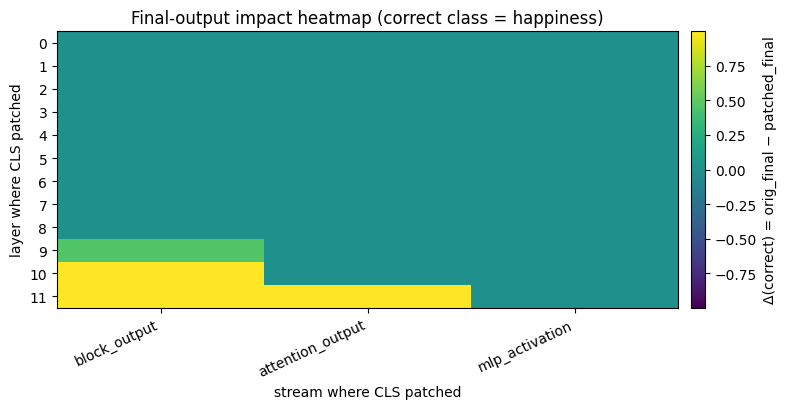

In [ ]:
TRUE_C = int(orig_final.argmax())
orig_c = float(orig_final[TRUE_C])

Dcorr = np.zeros((len(layers), len(streams)), dtype=np.float32)
for i in range(len(layers)):
    for j in range(len(streams)):
        Dcorr[i, j] = orig_c - float(P[i, j, TRUE_C])

finite = Dcorr[np.isfinite(Dcorr)]
v = float(np.quantile(np.abs(finite), 0.99)) if finite.size else 1e-6
v = max(v, 1e-6)

plt.figure(figsize=(8, max(4, 0.35*len(layers))))
im = plt.imshow(Dcorr, aspect="auto", interpolation="nearest", vmin=-v, vmax=v)
plt.colorbar(im, fraction=0.03, pad=0.02, label="Δ(correct) = orig_final − patched_final")
plt.yticks(np.arange(len(layers)), layers)
plt.xticks(np.arange(len(streams)), streams, rotation=25, ha="right")
plt.xlabel("stream where CLS patched")
plt.ylabel("layer where CLS patched")
plt.title(f"Final-output impact heatmap (correct class = {pretty_label(TRUE_C)})")
plt.tight_layout()
plt.show()


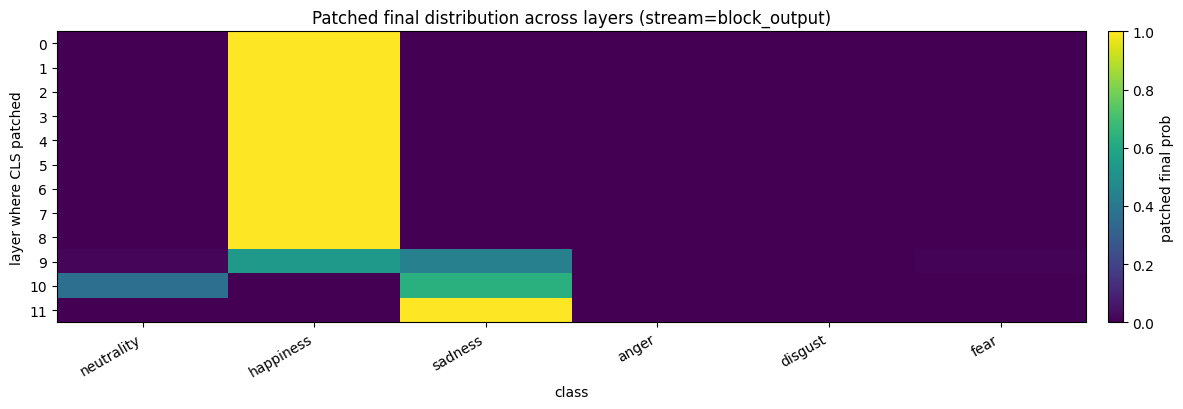

In [ ]:
STREAM_TO_PLOT = streams[0]
j = streams.index(STREAM_TO_PLOT)

M = P[:, j, :]
plt.figure(figsize=(12, max(4, 0.35*len(layers))))
im = plt.imshow(M, aspect="auto", interpolation="nearest", vmin=0.0, vmax=1.0)
plt.colorbar(im, fraction=0.03, pad=0.02, label="patched final prob")
plt.yticks(np.arange(len(layers)), layers)
plt.xticks(np.arange(C), [pretty_label(i) for i in range(C)], rotation=30, ha="right")
plt.xlabel("class")
plt.ylabel("layer where CLS patched")
plt.title(f"Patched final distribution across layers (stream={STREAM_TO_PLOT})")
plt.tight_layout()
plt.show()


In [27]:
rows = []
for i,L in enumerate(layers):
    for j,s in enumerate(streams):
        patched = P[i,j]
        rows.append({
            "layer": L,
            "stream": s,
            "delta_correct": float(orig_final[TRUE_C] - patched[TRUE_C]),
            "patched_pred": int(patched.argmax()),
            "patched_p_correct": float(patched[TRUE_C]),
            "patched_p_pred": float(patched[int(patched.argmax())]),
        })

rows_sorted = sorted(rows, key=lambda r: r["delta_correct"], reverse=True)

print("Top 15 most damaging (largest drop in p(correct)):")
for r in rows_sorted[:15]:
    print(
        f"L={r['layer']:2d}  {r['stream']:<16}  "
        f"Δp(correct)={r['delta_correct']:+.6f}  "
        f"p_correct={r['patched_p_correct']:.6f}  "
        f"pred={pretty_label(r['patched_pred'])} (p={r['patched_p_pred']:.6f})"
    )


Top 15 most damaging (largest drop in p(correct)):
L=11  block_output      Δp(correct)=+1.000000  p_correct=0.000000  pred=sadness (p=0.999870)
L=10  block_output      Δp(correct)=+0.999949  p_correct=0.000051  pred=sadness (p=0.634758)
L=11  attention_output  Δp(correct)=+0.999722  p_correct=0.000278  pred=sadness (p=0.750008)
L= 9  block_output      Δp(correct)=+0.458797  p_correct=0.541203  pred=happiness (p=0.541203)
L=11  mlp_activation    Δp(correct)=+0.000006  p_correct=0.999994  pred=happiness (p=0.999994)
L= 8  block_output      Δp(correct)=+0.000002  p_correct=0.999998  pred=happiness (p=0.999998)
L= 9  attention_output  Δp(correct)=+0.000002  p_correct=0.999998  pred=happiness (p=0.999998)
L=10  attention_output  Δp(correct)=+0.000001  p_correct=0.999999  pred=happiness (p=0.999999)
L= 8  mlp_activation    Δp(correct)=+0.000000  p_correct=1.000000  pred=happiness (p=1.000000)
L=10  mlp_activation    Δp(correct)=+0.000000  p_correct=1.000000  pred=happiness (p=1.000000)
L= 4 